# 中立化した AI スコアの評価（単独と comp_ew との複合）

`04_style_tilt` で AI スコア（`ens_lgbm_dnn`）が低ボラ・大型に寄っており、最適化の制約下でその部分が吸収されることが分かった。
`scripts/build_neutralize.py` で各月ユニバース内の回帰残差として中立化した版を作り、単独と `comp_ew` との複合を評価する。

| スコア | 中立化の説明変数 |
| --- | --- |
| `ens_lgbm_dnn_neu` | log 時価総額 + `vola60` + GICS セクターダミー |
| `ens_lgbm_dnn_neu_sz` | log 時価総額 + GICS セクターダミー（`comp_ew` と同じ処理） |
| `comp_ew_{w}_ai_neu_{100−w}` | `comp_ew` × `ens_lgbm_dnn_neu`（Blom 加重平均 → 再 Blom） |

**規約**: Q5 = スコア最上位。リターンは `drtn`（配当込み）と `srtn`（固有）。累積は drtn が複利、srtn が累和。
税は信託扱い・INR 建て、売買コスト 15/25bp、バーンイン 12 か月。ベンチマークは MSCI India。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, compute_alpha_report, india_tax_schedule, plot_cross_alpha_bars, plot_cumulative, summary_table

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

INPUT_ROOT = "../../input/msci_india_imi"
SCORES = {'comp_ew': 'composite/comp_ew', 'ens_lgbm_dnn (生)': 'my_ai/ens_lgbm_dnn', 'ens_lgbm_dnn_neu': 'my_ai_neu/ens_lgbm_dnn_neu', 'ens_lgbm_dnn_neu_sz': 'my_ai_neu/ens_lgbm_dnn_neu_sz', 'comp_ew_90_ai_neu_10': 'composite/comp_ew_90_ai_neu_10', 'comp_ew_80_ai_neu_20': 'composite/comp_ew_80_ai_neu_20', 'comp_ew_70_ai_neu_30': 'composite/comp_ew_70_ai_neu_30', 'comp_ew_60_ai_neu_40': 'composite/comp_ew_60_ai_neu_40', 'comp_ew_50_ai_neu_50': 'composite/comp_ew_50_ai_neu_50'}
HIGHLIGHT = ["comp_ew", "ens_lgbm_dnn_neu", "comp_ew_70_ai_neu_30"]
W = [90, 80, 70, 60, 50]
BENCHMARK = "msci_india"
RISK_MODEL = "GEMLT"
RETURN_KINDS = {"drtn": "rtn", "srtn": "srtn"}
START, END = 201212, 202606
N_QUANTILES = 5
BUFFER = 0.0
CW_MAX_WEIGHT = 0.05
COST_BUY, COST_SELL = 0.0015, 0.0025
FPI_TYPE = "trust"
BURN_IN = 12

store = InputStore(INPUT_ROOT)

## 1. ティルトの確認（中立化の効果）

サイズ・`vola60`・モメンタム（`mom12_1`）との月次順位相関と、BM 加重平均。

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
log_size = np.log(univ.where(univ > 0))
vola = store.alpha("core/vola60", START, END).reindex(columns=univ.columns)
mom = store.alpha("core/mom12_1", START, END).reindex(columns=univ.columns)
scores = {name: store.alpha(path, START, END).reindex(columns=univ.columns) for name, path in SCORES.items()}

def row_corr(a, b):
    return float(np.mean([a.loc[d].rank().corr(b.loc[d].reindex(a.columns).rank()) for d in a.index]))

rows = {}
for name, s in scores.items():
    su = s.where(univ.reindex(index=s.index).notna())
    bmw = bm.reindex(index=su.index, columns=su.columns)
    rows[name] = {"corr(size)": row_corr(su, log_size), "corr(vola60)": row_corr(su, vola), "corr(mom12_1)": row_corr(su, mom), "BM 加重平均": float(((su * bmw).sum(axis=1) / bmw.sum(axis=1)).mean()), "銘柄数/月": float(su.notna().sum(axis=1).mean())}
display(pd.DataFrame(rows).T.round(3))

,corr(size),corr(vola60),corr(mom12_1),BM 加重平均,銘柄数/月
comp_ew,0.040,-0.106,0.587,-0.145,399.074
ens_lgbm_dnn (生),0.313,-0.506,0.325,0.521,399.098
ens_lgbm_dnn_neu,0.005,-0.001,0.331,-0.277,398.374
ens_lgbm_dnn_neu_sz,0.008,-0.387,0.260,-0.129,399.098
comp_ew_90_ai_neu_10,0.038,-0.099,0.583,-0.163,399.074
comp_ew_80_ai_neu_20,0.036,-0.091,0.573,-0.182,399.074
comp_ew_70_ai_neu_30,0.033,-0.082,0.558,-0.201,399.074
comp_ew_60_ai_neu_40,0.030,-0.072,0.537,-0.217,399.074
comp_ew_50_ai_neu_50,0.027,-0.061,0.511,-0.233,399.074


## 2. 一括計算

In [3]:
returns = {kind: store.returns(RISK_MODEL, col, START, 202607) for kind, col in RETURN_KINDS.items()}
schedule = india_tax_schedule(FPI_TYPE)
reports = {}
for name, score in scores.items():
    reports[name] = compute_alpha_report(name, score, univ, bm, returns, n_quantiles=N_QUANTILES, buffer=BUFFER, cw_max_weight=CW_MAX_WEIGHT, tax_schedule=schedule, cost_buy=COST_BUY, cost_sell=COST_SELL, burn_in=BURN_IN, tax_kind="drtn")
    print(f"{name:26s} done")
first = next(iter(reports.values()))
print(f"分位ラベル: 最上位 = {first.top}。評価期間 {first.series['ew_excess']['drtn'].index.min().date()} 〜 {first.series['ew_excess']['drtn'].index.max().date()}")

comp_ew                    done


ens_lgbm_dnn (生)           done


ens_lgbm_dnn_neu           done


ens_lgbm_dnn_neu_sz        done


comp_ew_90_ai_neu_10       done


comp_ew_80_ai_neu_20       done


comp_ew_70_ai_neu_30       done


comp_ew_60_ai_neu_40       done


comp_ew_50_ai_neu_50       done
分位ラベル: 最上位 = Q5。評価期間 2014-01-31 〜 2026-07-31


## 3. 指標表

In [4]:
tbl = summary_table(reports)
print("drtn（配当込みトータルリターン）")
display(tbl["drtn"].round(3))
print("srtn（固有リターン）")
display(tbl["srtn"].round(3))
display(tbl["共通"].round(3))
print("分位別の年率リターン（drtn、Q5 = 最上位）")
display(pd.DataFrame({name: rep.quantile_returns["drtn"].drop(columns="spread").mean() * 12 for name, rep in reports.items()}).T.round(3))

drtn（配当込みトータルリターン）


指標,Q5 EW 超過 (vs BM),Q5 EW 超過 (vs BM) IR,Q5 − Q1,Q5 − Q1 IR,Q5 CW 超過 (vs BM),Q5 CW 超過 (vs BM) IR,税控除後 Q5 EW 超過 (vs BM),税控除後 Q5 EW 超過 (vs BM) IR,IC,ICIR,IC t
comp_ew,0.132,1.157,0.173,1.314,0.096,1.082,0.080,0.740,0.054,0.480,5.901
ens_lgbm_dnn (生),0.109,1.288,0.163,1.008,0.054,0.821,0.050,0.648,0.074,0.536,6.591
ens_lgbm_dnn_neu,0.127,1.191,0.182,2.029,0.097,1.086,0.064,0.657,0.065,0.809,9.946
ens_lgbm_dnn_neu_sz,0.127,1.301,0.189,1.509,0.105,1.388,0.065,0.724,0.069,0.657,8.078
comp_ew_90_ai_neu_10,0.131,1.161,0.181,1.422,0.098,1.117,0.079,0.737,0.057,0.516,6.336
comp_ew_80_ai_neu_20,0.137,1.220,0.187,1.484,0.104,1.135,0.083,0.786,0.060,0.557,6.839
comp_ew_70_ai_neu_30,0.144,1.264,0.197,1.625,0.106,1.113,0.087,0.818,0.063,0.597,7.331
comp_ew_60_ai_neu_40,0.144,1.269,0.206,1.749,0.100,1.072,0.086,0.812,0.065,0.638,7.837
comp_ew_50_ai_neu_50,0.144,1.299,0.209,1.868,0.104,1.144,0.084,0.819,0.067,0.680,8.358


srtn（固有リターン）


指標,Q5 EW 超過 (vs BM),Q5 EW 超過 (vs BM) IR,Q5 − Q1,Q5 − Q1 IR,Q5 CW 超過 (vs BM),Q5 CW 超過 (vs BM) IR,税控除後 Q5 EW 超過 (vs BM),税控除後 Q5 EW 超過 (vs BM) IR,IC,ICIR,IC t
comp_ew,0.115,1.141,0.107,0.972,0.065,0.790,0.064,0.644,0.032,0.314,3.861
ens_lgbm_dnn (生),0.109,1.495,0.121,1.020,0.045,0.809,0.050,0.726,0.058,0.540,6.630
ens_lgbm_dnn_neu,0.123,1.393,0.134,1.700,0.084,1.093,0.060,0.705,0.050,0.658,8.080
ens_lgbm_dnn_neu_sz,0.134,1.585,0.159,1.657,0.107,1.548,0.071,0.889,0.057,0.673,8.272
comp_ew_90_ai_neu_10,0.115,1.146,0.116,1.082,0.067,0.828,0.063,0.644,0.035,0.348,4.282
comp_ew_80_ai_neu_20,0.122,1.236,0.122,1.154,0.074,0.895,0.068,0.710,0.038,0.387,4.752
comp_ew_70_ai_neu_30,0.130,1.326,0.132,1.278,0.077,0.917,0.073,0.771,0.041,0.426,5.231
comp_ew_60_ai_neu_40,0.130,1.342,0.142,1.412,0.074,0.882,0.072,0.770,0.044,0.466,5.724
comp_ew_50_ai_neu_50,0.132,1.402,0.145,1.486,0.078,0.965,0.073,0.794,0.046,0.507,6.225


指標,回転率 EW,回転率 CW,コストドラッグ,税ドラッグ,短期比率
comp_ew,4.049,4.167,0.017,0.033,0.807
ens_lgbm_dnn (生),5.165,5.057,0.021,0.036,0.938
ens_lgbm_dnn_neu,5.471,5.736,0.022,0.039,0.955
ens_lgbm_dnn_neu_sz,5.247,5.747,0.021,0.039,0.942
comp_ew_90_ai_neu_10,4.103,4.219,0.017,0.033,0.814
comp_ew_80_ai_neu_20,4.192,4.298,0.017,0.035,0.836
comp_ew_70_ai_neu_30,4.333,4.482,0.018,0.037,0.870
comp_ew_60_ai_neu_40,4.464,4.616,0.018,0.037,0.887
comp_ew_50_ai_neu_50,4.655,4.819,0.019,0.038,0.909


分位別の年率リターン（drtn、Q5 = 最上位）


,Q1,Q2,Q3,Q4,Q5
comp_ew,0.090,0.138,0.165,0.197,0.262
ens_lgbm_dnn (生),0.076,0.153,0.182,0.202,0.240
ens_lgbm_dnn_neu,0.076,0.129,0.167,0.218,0.258
ens_lgbm_dnn_neu_sz,0.068,0.144,0.174,0.209,0.258
comp_ew_90_ai_neu_10,0.080,0.143,0.169,0.199,0.261
comp_ew_80_ai_neu_20,0.081,0.137,0.166,0.201,0.268
comp_ew_70_ai_neu_30,0.078,0.127,0.171,0.201,0.275
comp_ew_60_ai_neu_40,0.068,0.133,0.173,0.205,0.274
comp_ew_50_ai_neu_50,0.066,0.124,0.184,0.204,0.274


## 4. 累積図（drtn 複利、srtn 累和、IC は累和と 36 か月移動平均）

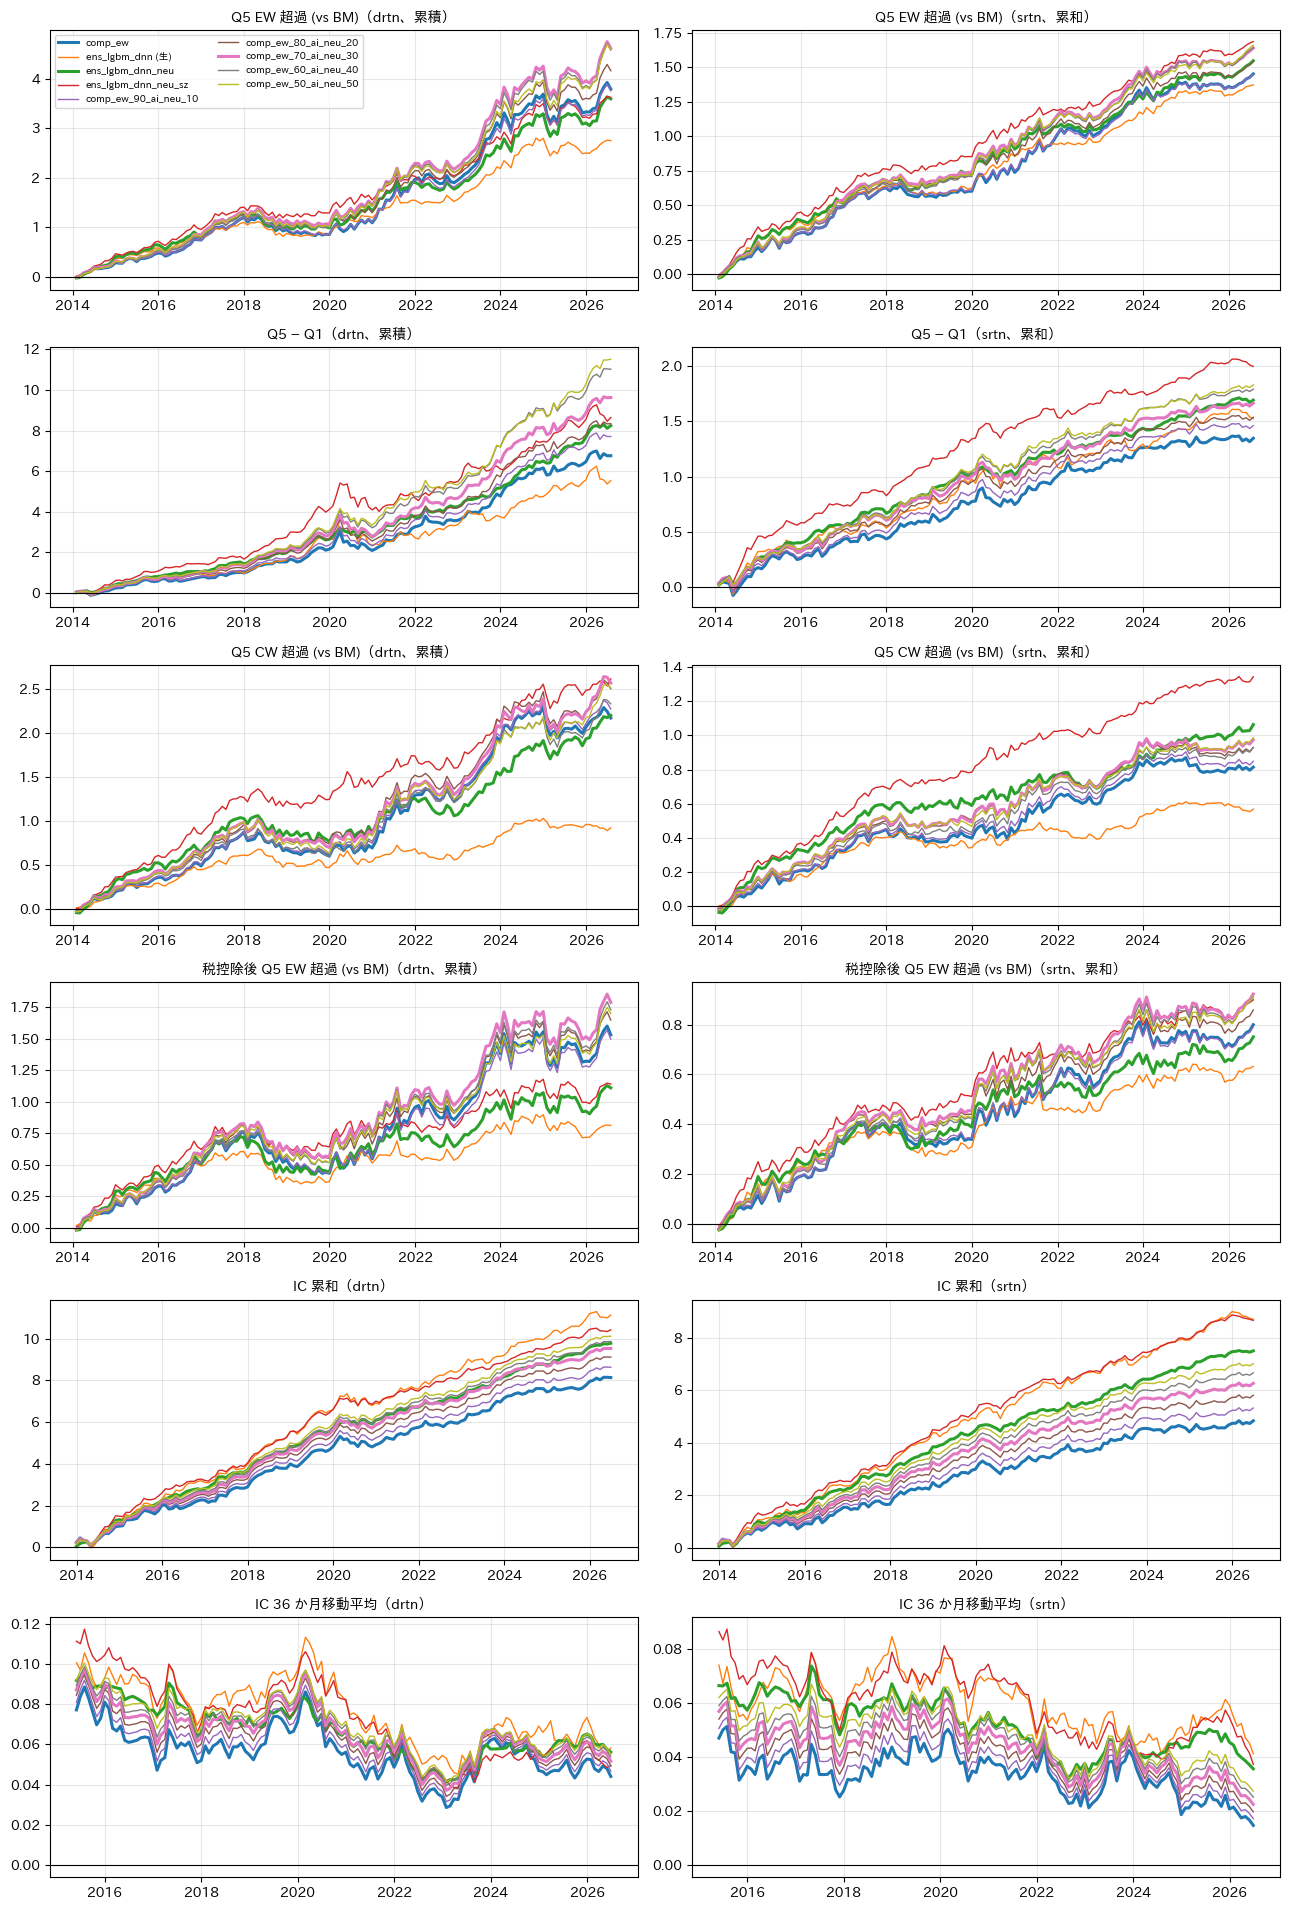

In [5]:
fig = plot_cumulative(reports, highlight=HIGHLIGHT)
plt.show()

## 5. アルファ横断の棒グラフ（年率、IC は平均）

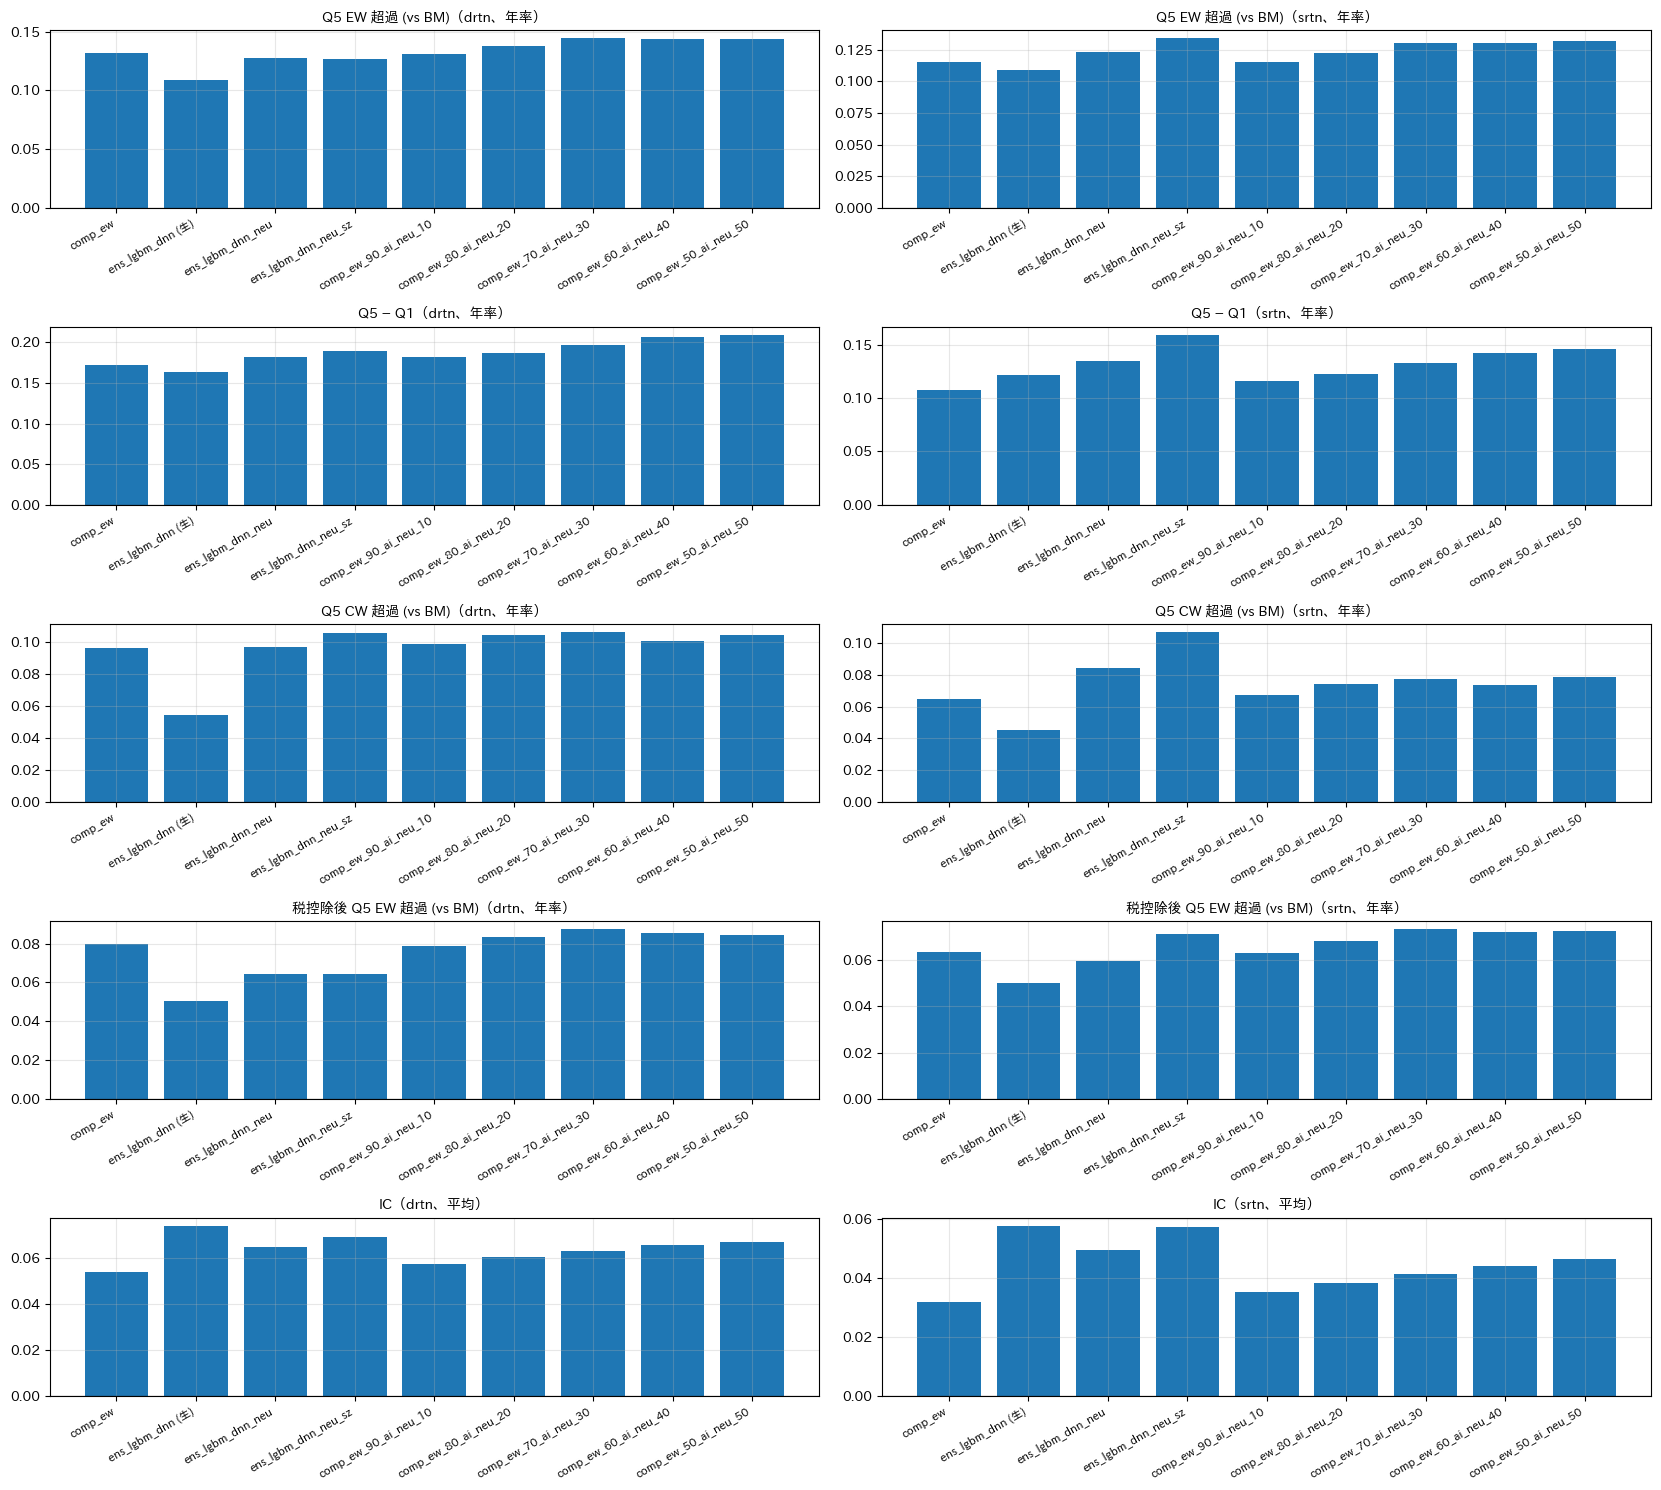

In [6]:
fig = plot_cross_alpha_bars(reports)
plt.show()

## 6. 混合比率と指標（中立化版との複合 vs 生スコアとの複合）

生スコアとの複合（`02_blend_comp_ai` と同じ `composite/comp_ew_{w}_ai_{..}`）を同条件で計算して並べる。

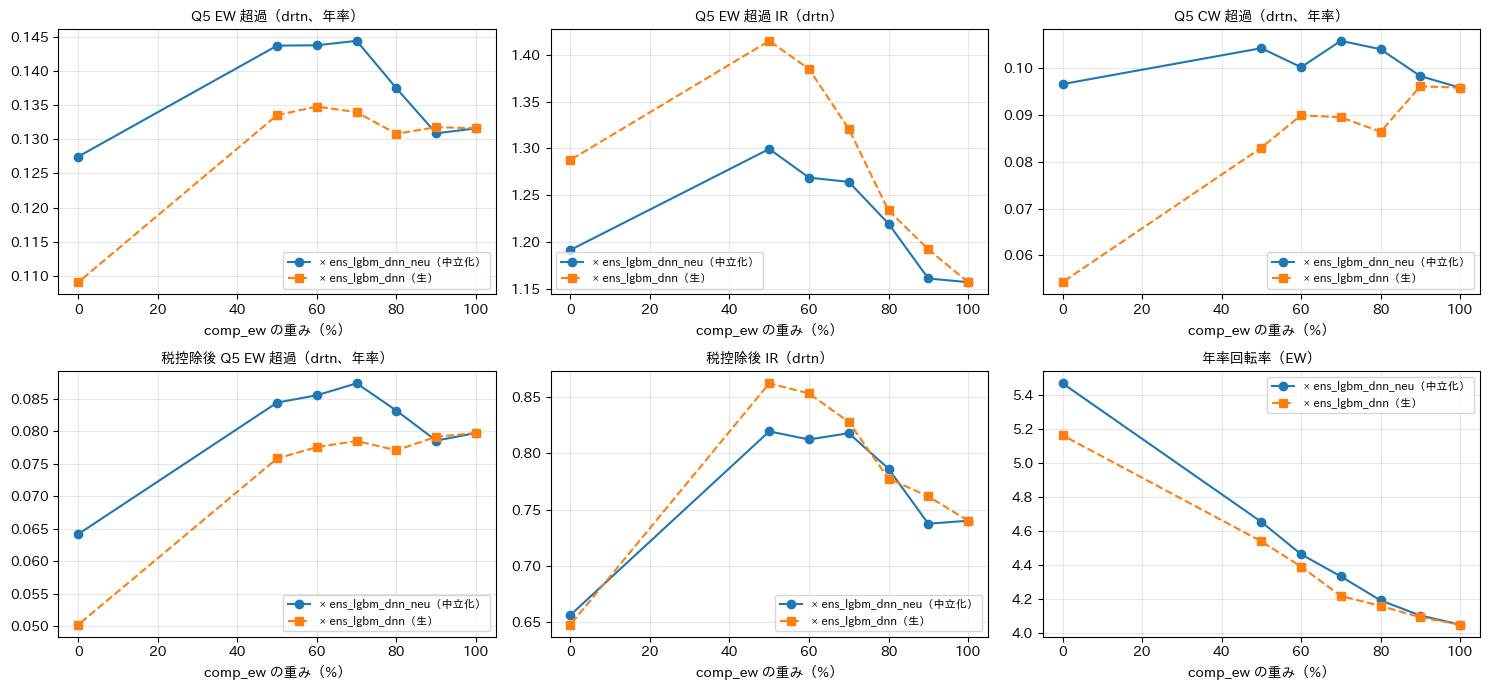

In [7]:
raw_blends = {f"comp_ew_{w}_ai_{100 - w}": f"composite/comp_ew_{w}_ai_{100 - w}" for w in W}
raw_blends["ens_lgbm_dnn (生)"] = "my_ai/ens_lgbm_dnn"
raw_reports = {}
for name, path in raw_blends.items():
    raw_reports[name] = reports[name] if name in reports else compute_alpha_report(name, store.alpha(path, START, END).reindex(columns=univ.columns), univ, bm, returns, n_quantiles=N_QUANTILES, buffer=BUFFER, cw_max_weight=CW_MAX_WEIGHT, tax_schedule=schedule, cost_buy=COST_BUY, cost_sell=COST_SELL, burn_in=BURN_IN, tax_kind="drtn")
tbl_raw = summary_table({**{"comp_ew": reports["comp_ew"]}, **raw_reports})

xw = [100] + W + [0]
fam_neu = ["comp_ew"] + [f"comp_ew_{w}_ai_neu_{100 - w}" for w in W] + ["ens_lgbm_dnn_neu"]
fam_raw = ["comp_ew"] + [f"comp_ew_{w}_ai_{100 - w}" for w in W] + ["ens_lgbm_dnn (生)"]
top = first.top
panels = [("drtn", f"{top} EW 超過 (vs BM)", "Q5 EW 超過（drtn、年率）"), ("drtn", f"{top} EW 超過 (vs BM) IR", "Q5 EW 超過 IR（drtn）"), ("drtn", f"{top} CW 超過 (vs BM)", "Q5 CW 超過（drtn、年率）"),
          ("drtn", f"税控除後 {top} EW 超過 (vs BM)", "税控除後 Q5 EW 超過（drtn、年率）"), ("drtn", f"税控除後 {top} EW 超過 (vs BM) IR", "税控除後 IR（drtn）"), ("共通", "回転率 EW", "年率回転率（EW）")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (kind, col, title) in zip(axes.ravel(), panels):
    ax.plot(xw, [tbl.loc[n, (kind, col)] for n in fam_neu], marker="o", label="× ens_lgbm_dnn_neu（中立化）")
    ax.plot(xw, [tbl_raw.loc[n, (kind, col)] for n in fam_raw], marker="s", linestyle="--", label="× ens_lgbm_dnn（生）")
    ax.set_xlabel("comp_ew の重み（%）")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 所見

評価期間 2014-01〜2026-07、Q5 = 最上位、等ウェイト（CW は時価総額ウェイト・上限 5%）。

**中立化の効果（ティルト）**

| | corr(size) | corr(vola60) | corr(mom12_1) | BM 加重平均 |
| --- | --- | --- | --- | --- |
| ens_lgbm_dnn（生） | +0.31 | −0.51 | +0.33 | +0.52 |
| ens_lgbm_dnn_neu | 0.00 | 0.00 | +0.33 | −0.28 |
| ens_lgbm_dnn_neu_sz | +0.01 | −0.39 | +0.26 | −0.13 |
| comp_ew | +0.04 | −0.11 | +0.59 | −0.15 |

サイズとボラのティルトは消え、モメンタムとの関係（0.33）はそのまま残る。中立化後の AI は `comp_ew` よりモメンタム依存が小さい。

**単独スコア（drtn）**

| | IC | ICIR | Q5 EW 超過 | IR | Q5 CW 超過 | CW IR | 税後 Q5 EW 超過 | 税後 IR | 回転率 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ens_lgbm_dnn（生） | 0.074 | 0.54 | 10.9% | 1.29 | 5.4% | 0.82 | 5.0% | 0.65 | 517% |
| **ens_lgbm_dnn_neu** | 0.065 | **0.81** | 12.7% | 1.19 | **9.7%** | 1.09 | 6.4% | 0.66 | 547% |
| ens_lgbm_dnn_neu_sz | 0.069 | 0.66 | 12.7% | 1.30 | **10.5%** | **1.39** | 6.5% | 0.72 | 525% |
| comp_ew | 0.054 | 0.48 | 13.2% | 1.16 | 9.6% | 1.08 | 8.0% | 0.74 | 405% |

- 中立化で IC は 0.074 → 0.065 に下がるが **ICIR は 0.54 → 0.81（t 値 9.9）** に上がる。04 の残差 IC の結果と整合。
- **時価総額ウェイトの超過が 5.4% → 9.7〜10.5% に倍増**。生スコアのサイズ・低ボラティルトが大型株での超過を潰していた。
  等ウェイトの超過も 10.9% → 12.7% で、`comp_ew`（13.2%）に迫る。
- Q5−Q1 の IR は 1.0 → 2.0（neu）。ロング・ショートでは中立化版が圧倒的に安定。固有リターンでの Q5 EW IR も 1.39〜1.59。
- `neu_sz`（サイズ + セクターのみ）は CW で最良（10.5%、IR 1.39）だがボラティルト（−0.39）が残り、最適化の制約下では
  リスクインデックス ±2sd に当たる可能性がある。制約下での比較は最適化後に判断。
- 回転率は 517% → 547% と上がり（中立化で短期的な残差が増える）、税後では `comp_ew` に届かない（6.4% vs 8.0%）。

**comp_ew との複合（中立化版、drtn）**

| comp:ai_neu | IC | Q5 EW 超過 | IR | Q5 CW 超過 | 税後 Q5 EW 超過 | 税後 IR | 回転率 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 100:0 | 0.054 | 13.2% | 1.16 | 9.6% | 8.0% | 0.74 | 405% |
| 80:20 | 0.060 | 13.7% | 1.22 | 10.4% | 8.3% | 0.79 | 419% |
| **70:30** | 0.063 | **14.4%** | 1.26 | **10.6%** | **8.7%** | **0.82** | 433% |
| 60:40 | 0.065 | 14.4% | 1.27 | 10.0% | 8.6% | 0.81 | 446% |
| 50:50 | 0.067 | 14.4% | 1.30 | 10.4% | 8.4% | 0.82 | 466% |

- 生スコアとの複合（`02`）では超過が 13.1〜13.5% で横ばいだったのに対し、**中立化版との複合は超過そのものが上がる**
  （13.2% → 14.4%）。CW でも 9.6% → 10.6%、税後でも 8.0% → 8.7% と、`comp_ew` 単体をすべての指標で上回る。
- 比率は 70:30〜50:50 でほぼ同じ。回転率と税ドラッグは AI 比率とともに上がるので、**70:30（`comp_ew_70_ai_neu_30`）** を第一候補にする。
- 固有リターンでも 70:30 で Q5 EW 超過 13.0%（IR 1.33）、IC 0.041 と `comp_ew`（11.5%、0.032）を上回る。

**判断**

1. 最適化に入れるスコアは **`comp_ew_70_ai_neu_30`**（次点 60:40、50:50）。比較用に `ens_lgbm_dnn_neu` 単独と `ens_lgbm_dnn_neu_sz` も回す。
2. `03_bax_results` で AI 単体の実現率が 31% だった原因（サイズ・低ボラティルトの吸収）は中立化で解消されるはずで、最適化後の
   実現率が `comp_ew` 並み（50%）になれば、制約下でも複合の優位（IR +0.1 前後）が残る見込み。
3. india-ai-model 側では、学習目的を最初からサイズ・ボラ中立にする（ターゲットを中立化残差にする、または特徴量からサイズ・ボラを外す）
   選択肢がある。事後の回帰残差より情報の損失が小さい可能性がある。